In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv('train.csv')
df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
from sklearn.model_selection import train_test_split,GridSearchCV

In [68]:
X = df.iloc[:, 1:].values
y=df.iloc[:, 0].values

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=41)

In [70]:
X_train.shape

(33600, 784)

In [71]:
y_train.shape

(33600,)

In [72]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
clf = DecisionTreeClassifier()

In [73]:
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [74]:
prediction_without_tuning = clf.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score
print(f"The accuracy of the model without tuning is : {accuracy_score(y_test, prediction_without_tuning)}")

The accuracy of the model without tuning is : 0.8577380952380952


In [76]:
param_dict = {
    'max_depth':[4,8,10,None],
    'min_samples_split':[8,10, 12]
}

In [77]:
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_dict,
    cv=5,
    n_jobs= -1
)

In [78]:
from sklearn.metrics import classification_report, accuracy_score

In [79]:
grid.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [4, 8, ...], 'min_samples_split': [8, 10, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [80]:
y_pred = grid.predict(X_test)

In [81]:
print(grid.best_estimator_)

DecisionTreeClassifier(min_samples_split=10)


In [82]:
y_pred.shape

(8400,)

In [83]:
y_pred

array([8, 4, 3, ..., 6, 6, 5], shape=(8400,))

In [84]:
print(f"The accuracy of the model is : {accuracy_score(y_test, y_pred)}")

The accuracy of the model is : 0.8572619047619048


In [85]:
print(f"The classification report after tuning is : {classification_report(y_test, y_pred)}")

The classification report after tuning is :               precision    recall  f1-score   support

           0       0.93      0.92      0.93       842
           1       0.93      0.93      0.93       906
           2       0.80      0.84      0.82       834
           3       0.83      0.79      0.81       867
           4       0.83      0.85      0.84       812
           5       0.80      0.81      0.81       732
           6       0.91      0.90      0.91       830
           7       0.89      0.90      0.89       928
           8       0.81      0.78      0.80       840
           9       0.82      0.83      0.83       809

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



In [86]:
y_test[100]

np.int64(1)

In [87]:
print(type(X_test[100]))

<class 'numpy.ndarray'>


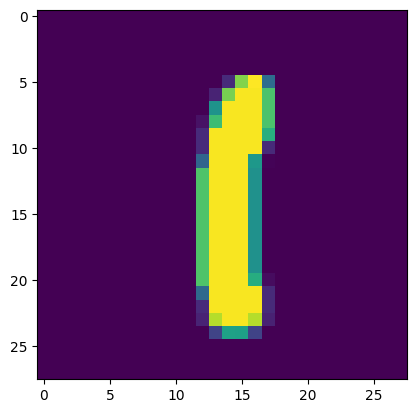

In [88]:
plt.imshow(X_test[100].reshape(28, 28))         #NOTE: To print the digit using one column

In [89]:
grid.predict(X_test[100].reshape(1, 784))

array([1])

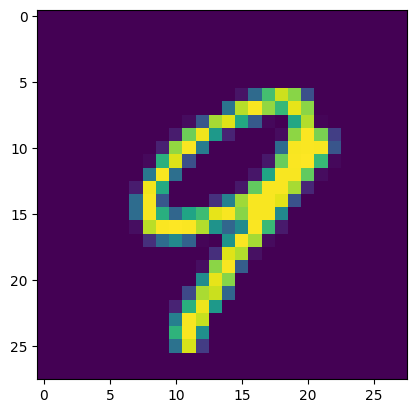

In [90]:
plt.imshow(X_test[1000].reshape(28, 28))

In [91]:
grid.predict(X_test[1000].reshape(1, 784))

array([9])

# MODEL

In [94]:
def predict_digit(pixel_value):
    print(type(pixel_value))

    pixel_value = np.array(pixel_value).reshape(1, 784)

    prediction = grid.predict(pixel_value)
    print(f"Predicted digits: ", prediction)
    
    plt.imshow(pixel_value.reshape(28, 28), cmap='gray')
    plt.show()


<class 'list'>
Predicted digits:  [6]


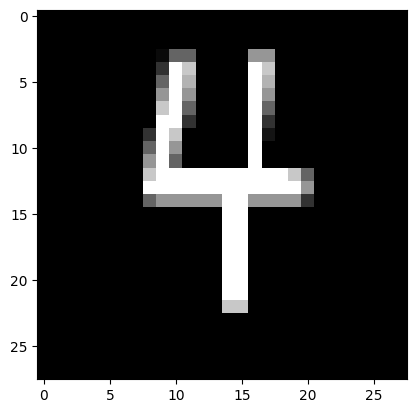

In [100]:
pixel_value_6 = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,10,80,150,200,200,150,50,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,50,180,250,255,255,255,255,255,255,100,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,100,240,255,200,100,50,50,50,50,50,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,150,255,200,50,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,180,255,150,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,200,255,50,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,200,255,50,0,0,80,180,220,220,180,80,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,200,255,180,220,255,255,255,255,255,255,255,180,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,200,255,255,255,200,150,100,100,150,200,255,255,100,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,180,255,200,100,0,0,0,0,0,100,200,255,200,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,150,255,150,0,0,0,0,0,0,50,180,255,220,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,100,255,150,0,0,0,0,0,0,50,180,255,220,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,50,255,200,0,0,0,0,0,0,50,180,255,220,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,20,240,255,100,0,0,0,0,0,100,220,255,180,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,180,255,255,180,100,50,50,100,180,255,250,100,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,50,200,255,255,255,255,255,255,255,255,180,20,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,50,150,220,255,255,255,255,200,100,20,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,20,100,150,150,100,20,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]

digit_4_data = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,10,100,100,0,0,0,0,150,150,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,50,255,200,0,0,0,0,255,200,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,100,255,180,0,0,0,0,255,180,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,150,255,150,0,0,0,0,255,150,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,200,255,100,0,0,0,0,255,100,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,255,255,50,0,0,0,0,255,50,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,50,255,200,0,0,0,0,0,255,20,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,100,255,150,0,0,0,0,0,255,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,150,255,100,0,0,0,0,0,255,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,200,255,255,255,255,255,255,255,255,255,255,200,100,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,255,255,255,255,255,255,255,255,255,255,255,255,150,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,100,150,150,150,150,150,255,255,150,150,150,150,50,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,255,255,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,255,255,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,255,255,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,255,255,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,255,255,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,255,255,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,255,255,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,200,200,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]

predict_digit(digit_4_data)